In [ ]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "README.md").is_file() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / "README.md").is_file():
    raise FileNotFoundError("Run this notebook from the project directory or one of its subdirectories.")


# Problem 3 — iTransformer + Optuna Feature Group Selection

이 노트북은 **전처리 완료 데이터셋을 입력받아 모델 학습/튜닝/평가만 수행**합니다.

## Pipeline
1. `train_final_physics.csv` 로드
2. `hs`, `tp`는 항상 사용
3. 나머지 physics feature는 **그룹 단위로 Optuna가 선택**
4. 동일 sample / 동일 temporal split / train-only scaling 고정
5. iTransformer hyperparameter도 Optuna가 함께 탐색
6. Best trial 설정으로 재학습
7. +3/+6/+9/+12/+18/+24h RMSE 및 Overall RMSE 출력
8. 모델 / scaler / trial / 결과 저장

> EDA, 이상치 처리, 결측 처리, feature 생성은 이 노트북에서 하지 않습니다.


In [1]:
# ============================================================
# 0. IMPORTS & CONFIG
# ============================================================

try:
    import optuna
except ImportError:
    !pip -q install optuna
    import optuna

import os
from pathlib import Path
import gc
import time
import random
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------
SEED = 42

def seed_everything(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything()

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------------------
# Data
# ------------------------------------------------------------
TRAIN_PATH = Path(PROJECT_ROOT / "data" / "processed" / "train_final_physics_v4.csv")
TEST_CONTEXT_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_context.parquet")
TEST_INDEX_PATH = Path(PROJECT_ROOT / "data" / "raw" / "test_index.csv")
SUBMISSION_PATH = Path(PROJECT_ROOT / "submission" / "submission_exp01.csv")

TIME_COL = "time"
STATION_COL = "station"
TARGET_COL = "hs"

# 10-minute interval
INPUT_LEN = 289
LEAD_HOURS = [3, 6, 9, 12, 18, 24]
LEAD_STEPS = [h * 6 for h in LEAD_HOURS]

# ------------------------------------------------------------
# Optuna
# ------------------------------------------------------------
N_TRIALS = 30
OPTUNA_MAX_EPOCHS = 30
OPTUNA_PATIENCE = 6

# ------------------------------------------------------------
# Final retraining
# ------------------------------------------------------------
FINAL_MAX_EPOCHS = 100
FINAL_PATIENCE = 10

# ------------------------------------------------------------
# Output
# ------------------------------------------------------------
EXPERIMENT_DIR = PROJECT_ROOT / "artifacts" / "experiments" / "exp01"
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = EXPERIMENT_DIR / "itransformer_optuna_best.pt"
SCALER_PATH = EXPERIMENT_DIR / "itransformer_optuna_scalers.pkl"
TRIALS_PATH = EXPERIMENT_DIR / "optuna_trials.csv"
BEST_PARAMS_PATH = EXPERIMENT_DIR / "optuna_best_params.csv"
RESULT_PATH = EXPERIMENT_DIR / "final_validation_result.csv"

print("Device:", DEVICE)
print("Train path:", TRAIN_PATH)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 25.4 MB/s eta 0:00:00
Device: cuda
Train path: /content/train_final_physics.csv


In [2]:
# ============================================================
# LOAD DATA + 파생변수 생성 + FEATURE REGISTRY
# ============================================================

train = pd.read_csv(
    TRAIN_PATH,
    parse_dates=[TIME_COL],
)

train = (
    train
    .sort_values([STATION_COL, TIME_COL])
    .reset_index(drop=True)
)

# Features not stored in the compact final dataset are rebuilt here.
station_groups = train.groupby(STATION_COL)
wind_radians = np.deg2rad(train["wdir"])
train["u_wind"] = train["wspd"] * np.sin(wind_radians)
train["v_wind"] = train["wspd"] * np.cos(wind_radians)
train["wspd_mean_6h"] = station_groups["wspd"].transform(lambda x: x.rolling(36, min_periods=1).mean())
train["wspd_mean_12h"] = station_groups["wspd"].transform(lambda x: x.rolling(72, min_periods=1).mean())
train["gust_max_6h"] = station_groups["gust"].transform(lambda x: x.rolling(36, min_periods=1).max())
train["gust_max_12h"] = station_groups["gust"].transform(lambda x: x.rolling(72, min_periods=1).max())
train["gust_minus_wspd"] = train["gust"] - train["wspd"]
angle_difference = np.deg2rad(train["wdir"] - train["wvdir"])
train["wind_wave_alignment"] = np.cos(angle_difference)
train["wind_wave_diff"] = np.abs((train["wdir"] - train["wvdir"] + 180) % 360 - 180)
train["caph_change_6h"] = train["caph"] - station_groups["caph"].shift(36)
train["caph_change_12h"] = train["caph"] - station_groups["caph"].shift(72)

print("Loaded shape:", train.shape)


# ============================================================
# 1. 필요한 파생변수 생성
# ============================================================

# 풍속 비선형
train["wspd2"] = train["wspd"] ** 2
train["wspd3"] = train["wspd"] ** 3

# 파고-주기 관계
train["wave_steepness_proxy"] = (
    train["hs"]
    /
    (train["tp"] ** 2 + 1e-6)
)

train["hs_tp_ratio"] = (
    train["hs"]
    /
    (train["tp"] + 1e-6)
)


# ============================================================
# 2. 기본 Feature
# ============================================================

BASE_FEATURES = [
    "hs",
    "tp",
]


# ============================================================
# 3. Optuna 후보 Feature Group
# ============================================================

FEATURE_GROUPS = {

    "wave_state": [
        "hmax",
    ],

    "meteo": [
        "airt",
        "relh",
        "caph",
    ],

    "wind_basic": [
        "wspd",
        "gust",
    ],

    "wind_vector": [
        "u_wind",
        "v_wind",
    ],

    "wind_history": [
        "wspd_mean_6h",
        "wspd_mean_12h",
    ],

    "gust_history": [
        "gust_max_6h",
        "gust_max_12h",
        "gust_minus_wspd",
    ],

    "direction": [
        "wind_wave_alignment",
        "wind_wave_diff",
    ],

    "pressure_change": [
        "caph_change_6h",
        "caph_change_12h",
    ],

    "wind_nonlinear": [
        "wspd2",
        "wspd3",
    ],

    "wave_physics": [
        "wave_steepness_proxy",
        "hs_tp_ratio",
    ],
}


# ============================================================
# 4. 전체 후보 Feature
# ============================================================

ALL_FEATURES = BASE_FEATURES.copy()

for cols in FEATURE_GROUPS.values():
    ALL_FEATURES.extend(cols)

ALL_FEATURES = list(
    dict.fromkeys(ALL_FEATURES)
)


# ============================================================
# 5. 존재 여부 확인
# ============================================================

missing = [
    c
    for c in ALL_FEATURES
    if c not in train.columns
]

if missing:
    raise ValueError(
        f"없는 후보 feature: {missing}"
    )


# ============================================================
# 6. 출력
# ============================================================

print("\nBASE FEATURES")
print(BASE_FEATURES)

print("\nFEATURE GROUPS")

for name, cols in FEATURE_GROUPS.items():
    print(
        f"{name:18s}: {cols}"
    )

print(
    f"\n전체 후보 Feature 수: "
    f"{len(ALL_FEATURES)}"
)

print("\nALL FEATURES")

for f in ALL_FEATURES:
    print(" -", f)

Loaded shape: (183600, 23)

BASE FEATURES
['hs', 'tp']

FEATURE GROUPS
wave_state        : ['hmax']
meteo             : ['airt', 'relh', 'caph']
wind_basic        : ['wspd', 'gust']
wind_vector       : ['u_wind', 'v_wind']
wind_history      : ['wspd_mean_6h', 'wspd_mean_12h']
gust_history      : ['gust_max_6h', 'gust_max_12h', 'gust_minus_wspd']
direction         : ['wind_wave_alignment', 'wind_wave_diff']
pressure_change   : ['caph_change_6h', 'caph_change_12h']
wind_nonlinear    : ['wspd2', 'wspd3']
wave_physics      : ['wave_steepness_proxy', 'hs_tp_ratio']

전체 후보 Feature 수: 23

ALL FEATURES
 - hs
 - tp
 - hmax
 - airt
 - relh
 - caph
 - wspd
 - gust
 - u_wind
 - v_wind
 - wspd_mean_6h
 - wspd_mean_12h
 - gust_max_6h
 - gust_max_12h
 - gust_minus_wspd
 - wind_wave_alignment
 - wind_wave_diff
 - caph_change_6h
 - caph_change_12h
 - wspd2
 - wspd3
 - wave_steepness_proxy
 - hs_tp_ratio


In [3]:
# ============================================================
# 2. BUILD WINDOWS ONCE + FIXED TEMPORAL SPLIT + SCALE ONCE
# ============================================================

def create_samples(
    df,
    features,
    input_len=INPUT_LEN,
    lead_steps=LEAD_STEPS,
):
    X, y, meta = [], [], []

    max_lead = max(lead_steps)

    for station, g in df.groupby(STATION_COL):
        g = (
            g
            .sort_values(TIME_COL)
            .reset_index(drop=True)
        )

        feature_values = g[features].to_numpy(dtype=np.float32)
        target_values = g[TARGET_COL].to_numpy(dtype=np.float32)

        for end_idx in range(
            input_len - 1,
            len(g) - max_lead
        ):
            start_idx = end_idx - input_len + 1

            x = feature_values[start_idx:end_idx + 1]

            target_idx = [
                end_idx + step
                for step in lead_steps
            ]
            target = target_values[target_idx]

            # All trials must use the exact same valid windows.
            if not np.isfinite(x).all():
                continue

            if not np.isfinite(target).all():
                continue

            X.append(x)
            y.append(target)

            meta.append({
                STATION_COL: station,
                TIME_COL: g.loc[end_idx, TIME_COL],
            })

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        pd.DataFrame(meta),
    )


# Defensive rebuild: this cell can be rerun independently after a kernel reset.
train["wspd2"] = train["wspd"] ** 2
train["wspd3"] = train["wspd"] ** 3
train["wave_steepness_proxy"] = train["hs"] / (train["tp"] ** 2 + 1e-6)
train["hs_tp_ratio"] = train["hs"] / (train["tp"] + 1e-6)

model_df = train[
    [STATION_COL, TIME_COL] + ALL_FEATURES
].copy()

X_all_raw, y_all_raw, meta = create_samples(
    model_df,
    ALL_FEATURES,
)

print("Samples:", len(X_all_raw))
print("X:", X_all_raw.shape)
print("y:", y_all_raw.shape)

# ------------------------------------------------------------
# Fixed time split
# ------------------------------------------------------------
SPLIT_TIME = meta[TIME_COL].quantile(0.8)

train_mask = (
    meta[TIME_COL] < SPLIT_TIME
).to_numpy()

valid_mask = (
    meta[TIME_COL] >= SPLIT_TIME
).to_numpy()

X_train_raw = X_all_raw[train_mask]
X_valid_raw = X_all_raw[valid_mask]

y_train_raw = y_all_raw[train_mask]
y_valid_raw = y_all_raw[valid_mask]

meta_train = meta.loc[train_mask].reset_index(drop=True)
meta_valid = meta.loc[valid_mask].reset_index(drop=True)

print("\nSplit time:", SPLIT_TIME)
print("Train:", X_train_raw.shape, y_train_raw.shape)
print("Valid:", X_valid_raw.shape, y_valid_raw.shape)

# full arrays no longer needed
del X_all_raw, y_all_raw
gc.collect()

# ------------------------------------------------------------
# Scale ALL candidate features ONCE.
# StandardScaler scales each feature independently, so
# selecting columns after scaling is equivalent to scaling the
# selected columns separately, provided fit is train-only.
# ------------------------------------------------------------
n_all_features = len(ALL_FEATURES)

x_scaler = StandardScaler()

X_train_2d = X_train_raw.reshape(
    -1,
    n_all_features,
)

x_scaler.fit(X_train_2d)

X_train_all = (
    x_scaler
    .transform(X_train_2d)
    .reshape(X_train_raw.shape)
    .astype(np.float32, copy=False)
)

del X_train_2d

X_valid_all = (
    x_scaler
    .transform(
        X_valid_raw.reshape(
            -1,
            n_all_features,
        )
    )
    .reshape(X_valid_raw.shape)
    .astype(np.float32, copy=False)
)

y_scaler = StandardScaler()
y_scaler.fit(y_train_raw)

y_train_scaled = (
    y_scaler
    .transform(y_train_raw)
    .astype(np.float32, copy=False)
)

y_valid_scaled = (
    y_scaler
    .transform(y_valid_raw)
    .astype(np.float32, copy=False)
)

# raw X can be freed
del X_train_raw, X_valid_raw
gc.collect()

FEATURE_TO_IDX = {
    feature: idx
    for idx, feature in enumerate(ALL_FEATURES)
}

print("\nScaling complete")
print("X_train_all:", X_train_all.shape, X_train_all.dtype)
print("X_valid_all:", X_valid_all.shape, X_valid_all.dtype)


Samples: 58585
X: (58585, 289, 23)
y: (58585, 6)

Split time: 2025-02-21 11:40:00+09:00
Train: (46866, 289, 23) (46866, 6)
Valid: (11719, 289, 23) (11719, 6)

Scaling complete
X_train_all: (46866, 289, 23) float32
X_valid_all: (11719, 289, 23) float32


In [4]:
# ============================================================
# 3. DATASET + iTRANSFORMER
# ============================================================

class FeatureSubsetDataset(Dataset):
    def __init__(
        self,
        X_all,
        y,
        feature_indices,
    ):
        # from_numpy avoids an unnecessary full copy.
        self.X_all = torch.from_numpy(X_all)
        self.y = torch.from_numpy(y)
        self.feature_indices = torch.tensor(
            feature_indices,
            dtype=torch.long,
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X_all[idx].index_select(
            dim=1,
            index=self.feature_indices,
        )
        return x, self.y[idx]


class AttentionBlock(nn.Module):
    def __init__(
        self,
        d_model,
        n_heads,
        dropout,
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(d_model)

        self.attn = nn.MultiheadAttention(
            embed_dim=d_model,
            num_heads=n_heads,
            dropout=dropout,
            batch_first=True,
        )

        self.norm2 = nn.LayerNorm(d_model)

        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * 4),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 4, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        z = self.norm1(x)

        attn_out, _ = self.attn(
            z, z, z,
            need_weights=False,
        )

        x = x + attn_out
        x = x + self.ff(self.norm2(x))

        return x


class ITransformer(nn.Module):
    def __init__(
        self,
        seq_len,
        n_features,
        pred_len,
        d_model,
        n_heads,
        e_layers,
        dropout,
    ):
        super().__init__()

        self.enc_embedding = nn.Linear(
            seq_len,
            d_model,
        )

        self.blocks = nn.ModuleList([
            AttentionBlock(
                d_model=d_model,
                n_heads=n_heads,
                dropout=dropout,
            )
            for _ in range(e_layers)
        ])

        self.norm = nn.LayerNorm(d_model)

        self.head = nn.Linear(
            n_features * d_model,
            pred_len,
        )

    def forward(self, x):
        # [B,T,N] -> [B,N,T]
        x = x.transpose(1, 2)

        x = self.enc_embedding(x)

        for block in self.blocks:
            x = block(x)

        x = self.norm(x)
        x = x.reshape(x.size(0), -1)

        return self.head(x)


def feature_names_to_indices(features):
    return [
        FEATURE_TO_IDX[f]
        for f in features
    ]


def make_loaders(
    selected_features,
    batch_size,
):
    idx = feature_names_to_indices(
        selected_features
    )

    train_ds = FeatureSubsetDataset(
        X_train_all,
        y_train_scaled,
        idx,
    )

    valid_ds = FeatureSubsetDataset(
        X_valid_all,
        y_valid_scaled,
        idx,
    )

    train_loader = DataLoader(
        train_ds,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    valid_loader = DataLoader(
        valid_ds,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    return train_loader, valid_loader


In [5]:
# ============================================================
# 4. TRAINING UTILITIES
# ============================================================

def run_epoch(
    model,
    loader,
    criterion,
    optimizer=None,
):
    is_train = optimizer is not None

    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_n = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(
            DEVICE,
            non_blocking=True,
        )

        y_batch = y_batch.to(
            DEVICE,
            non_blocking=True,
        )

        if is_train:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_train):

            pred = model(X_batch)

            loss = criterion(
                pred,
                y_batch,
            )

        if is_train:

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )

            optimizer.step()

        bs = X_batch.size(0)

        total_loss += loss.item() * bs
        total_n += bs

    return total_loss / total_n


def train_model(
    selected_features,
    params,
    max_epochs,
    patience,
    trial=None,
    verbose=False,
):
    seed_everything(SEED)

    train_loader, valid_loader = make_loaders(
        selected_features,
        params["batch_size"],
    )

    model = ITransformer(
        seq_len=INPUT_LEN,
        n_features=len(selected_features),
        pred_len=len(LEAD_HOURS),
        d_model=params["d_model"],
        n_heads=params["n_heads"],
        e_layers=params["e_layers"],
        dropout=params["dropout"],
    ).to(DEVICE)

    criterion = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=3,
    )

    best_val = float("inf")
    best_epoch = 0
    best_state = None
    patience_count = 0

    history = {
        "train_loss": [],
        "val_loss": [],
    }

    for epoch in range(
        1,
        max_epochs + 1
    ):

        train_loss = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        val_loss = run_epoch(
            model,
            valid_loader,
            criterion,
        )

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val:

            best_val = val_loss
            best_epoch = epoch

            best_state = {
                k: v.detach().cpu().clone()
                for k, v
                in model.state_dict().items()
            }

            patience_count = 0

        else:
            patience_count += 1

        if trial is not None:

            trial.report(
                val_loss,
                step=epoch,
            )

            if trial.should_prune():

                del model
                gc.collect()

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

                raise optuna.TrialPruned()

        if verbose:

            print(
                f"Epoch {epoch:03d} | "
                f"Train {train_loss:.6f} | "
                f"Valid {val_loss:.6f} | "
                f"Best {best_val:.6f} | "
                f"Patience {patience_count}/{patience}"
            )

        if patience_count >= patience:
            break

    model.load_state_dict(best_state)

    return {
        "model": model,
        "best_state": best_state,
        "best_val": best_val,
        "best_epoch": best_epoch,
        "history": history,
        "valid_loader": valid_loader,
    }


def evaluate_model(
    model,
    valid_loader,
):
    model.eval()

    preds = []

    with torch.no_grad():

        for X_batch, _ in valid_loader:

            X_batch = X_batch.to(
                DEVICE,
                non_blocking=True,
            )

            pred = model(X_batch)

            preds.append(
                pred.cpu().numpy()
            )

    pred_scaled = np.concatenate(
        preds,
        axis=0,
    )

    pred = y_scaler.inverse_transform(
        pred_scaled
    )

    lead_rmse = []

    for i in range(len(LEAD_HOURS)):

        rmse = np.sqrt(
            mean_squared_error(
                y_valid_raw[:, i],
                pred[:, i],
            )
        )

        lead_rmse.append(float(rmse))

    overall_rmse = float(
        np.sqrt(
            np.mean(
                (y_valid_raw - pred) ** 2
            )
        )
    )

    return pred, lead_rmse, overall_rmse


In [7]:
# ============================================================
# 5. OPTUNA — FEATURE GROUP + MODEL HYPERPARAMETER SEARCH
# ============================================================

def select_features(trial):

    selected_features = BASE_FEATURES.copy()
    selected_groups = []

    for group_name, cols in FEATURE_GROUPS.items():

        use_group = trial.suggest_categorical(
            f"use_{group_name}",
            [False, True],
        )

        if use_group:

            selected_features.extend(cols)
            selected_groups.append(group_name)

    selected_features = list(
        dict.fromkeys(selected_features)
    )

    return selected_features, selected_groups

# ============================================================
# OPTUNA OBJECTIVE
# - 평가 기준: 실제 단위 Overall RMSE (meter)
# ============================================================

def objective(trial):

    # ========================================================
    # 1. Feature Selection
    # ========================================================

    selected_features, selected_groups = (
        select_features(trial)
    )

    trial.set_user_attr(
        "selected_features",
        selected_features,
    )

    trial.set_user_attr(
        "selected_groups",
        selected_groups,
    )

    trial.set_user_attr(
        "n_features",
        len(selected_features),
    )


    # ========================================================
    # 2. Hyperparameter Search
    # ========================================================

    params = {

        "d_model": trial.suggest_categorical(
            "d_model",
            [64, 128, 256],
        ),

        "n_heads": trial.suggest_categorical(
            "n_heads",
            [2, 4, 8],
        ),

        "e_layers": trial.suggest_int(
            "e_layers",
            2,
            4,
        ),

        "dropout": trial.suggest_float(
            "dropout",
            0.05,
            0.30,
        ),

        "lr": trial.suggest_float(
            "lr",
            1e-5,
            8e-5,
            log=True,
         ),

        "weight_decay": trial.suggest_float(
            "weight_decay",
            1e-6,
            1e-3,
            log=True,
        ),

        "batch_size": trial.suggest_categorical(
            "batch_size",
            [32, 64, 128],
        ),
    }


    # ========================================================
    # 3. Train
    # ========================================================

    result = train_model(
        selected_features=selected_features,
        params=params,
        max_epochs=OPTUNA_MAX_EPOCHS,
        patience=OPTUNA_PATIENCE,
        trial=trial,
        verbose=False,
    )


    model = result["model"]
    valid_loader = result["valid_loader"]


    # ========================================================
    # 4. Validation Prediction
    # ========================================================

    model.eval()

    preds_scaled = []

    with torch.no_grad():

        for X_batch, _ in valid_loader:

            X_batch = X_batch.to(
                DEVICE,
                non_blocking=True,
            )

            pred_batch = model(
                X_batch
            )

            preds_scaled.append(
                pred_batch
                .cpu()
                .numpy()
            )


    preds_scaled = np.concatenate(
        preds_scaled,
        axis=0,
    )


    # ========================================================
    # 5. 원래 hs 단위로 inverse scaling
    # ========================================================

    preds = (
        y_scaler
        .inverse_transform(
            preds_scaled
        )
    )


    # ========================================================
    # 6. Overall RMSE (meter)
    # ========================================================

    overall_rmse = float(
        np.sqrt(
            np.mean(
                (
                    y_valid_raw
                    -
                    preds
                ) ** 2
            )
        )
    )


    # ========================================================
    # 7. Lead별 RMSE도 기록
    # ========================================================

    lead_rmse = []

    for i, lead in enumerate(
        LEAD_HOURS
    ):

        rmse = float(
            np.sqrt(
                mean_squared_error(
                    y_valid_raw[:, i],
                    preds[:, i],
                )
            )
        )

        lead_rmse.append(
            rmse
        )

        trial.set_user_attr(
            f"rmse_{lead}h",
            rmse,
        )


    trial.set_user_attr(
        "best_epoch",
        result["best_epoch"],
    )

    trial.set_user_attr(
        "best_scaled_val_mse",
        result["best_val"],
    )

    trial.set_user_attr(
        "overall_rmse",
        overall_rmse,
    )


    print("\n" + "=" * 80)

    print(
        f"Trial {trial.number}"
    )

    print(
        "Groups:",
        selected_groups
    )

    print(
        "Features:",
        len(selected_features)
    )

    print(
        "Lead RMSE:",
        {
            f"{lead}h": round(rmse, 4)
            for lead, rmse
            in zip(
                LEAD_HOURS,
                lead_rmse
            )
        }
    )

    print(
        f"Overall RMSE: "
        f"{overall_rmse:.6f} m"
    )

    print("=" * 80)


    # ========================================================
    # 8. Memory Cleanup
    # ========================================================

    del model
    del valid_loader
    del result

    del preds_scaled
    del preds

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # ★ Optuna가 최소화할 실제 점수
    return overall_rmse

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(
        seed=SEED,
    ),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,
        n_warmup_steps=8,
    ),
    study_name="hs_itransformer_feature_optuna",
)

start_time = time.time()

study.optimize(
    objective,
    n_trials=N_TRIALS,
    gc_after_trial=True,
)

print("\n" + "=" * 80)
print("OPTUNA COMPLETE")
print("=" * 80)

best_trial = study.best_trial

print("Best trial:", best_trial.number)
print("Best validation RMSE (m):", best_trial.value)
print("Best epoch in trial:", best_trial.user_attrs["best_epoch"])

print("\nSelected groups:")
for g in best_trial.user_attrs["selected_groups"]:
    print(" -", g)

BEST_FEATURES = best_trial.user_attrs[
    "selected_features"
]

print("\nSelected features:")
for f in BEST_FEATURES:
    print(" -", f)

print("\nModel hyperparameters:")

MODEL_PARAM_NAMES = [
    "d_model",
    "n_heads",
    "e_layers",
    "dropout",
    "lr",
    "weight_decay",
    "batch_size",
]

BEST_MODEL_PARAMS = {
    k: best_trial.params[k]
    for k in MODEL_PARAM_NAMES
}

for k, v in BEST_MODEL_PARAMS.items():
    print(f"{k:15s}: {v}")

print(
    f"\nOptuna time: "
    f"{(time.time() - start_time) / 60:.1f} min"
)

trials_df = study.trials_dataframe(
    attrs=(
        "number",
        "value",
        "params",
        "user_attrs",
        "state",
    )
)

trials_df.to_csv(
    TRIALS_PATH,
    index=False,
    encoding="utf-8-sig",
)

best_params_df = pd.DataFrame([{
    "trial_number": best_trial.number,
    "validation_rmse": best_trial.value,
    "best_epoch": best_trial.user_attrs["best_epoch"],
    "selected_groups": ", ".join(best_trial.user_attrs["selected_groups"]),
    "selected_features": ", ".join(BEST_FEATURES),
    **BEST_MODEL_PARAMS,
}])
best_params_df.to_csv(
    BEST_PARAMS_PATH,
    index=False,
    encoding="utf-8-sig",
)

print("Trials saved:", TRIALS_PATH)
print("Best parameters saved:", BEST_PARAMS_PATH)


[I 2026-08-23 12:03:57,930] A new study created in memory with name: hs_itransformer_feature_optuna
[I 2026-08-23 12:05:42,411] Trial 0 finished with value: 0.5350115299224854 and parameters: {'use_wave_state': True, 'use_meteo': False, 'use_wind_basic': False, 'use_wind_vector': True, 'use_wind_history': True, 'use_gust_history': True, 'use_direction': False, 'use_pressure_change': True, 'use_wind_nonlinear': True, 'use_wave_physics': False, 'd_model': 64, 'n_heads': 8, 'e_layers': 2, 'dropout': 0.17855860960340292, 'lr': 3.427706793940999e-05, 'weight_decay': 1.3783237455007196e-06, 'batch_size': 32}. Best is trial 0 with value: 0.5350115299224854.



Trial 0
Groups: ['wave_state', 'wind_vector', 'wind_history', 'gust_history', 'pressure_change', 'wind_nonlinear']
Features: 14
Lead RMSE: {'3h': 0.2788, '6h': 0.3781, '9h': 0.4703, '12h': 0.5391, '18h': 0.6668, '24h': 0.7351}
Overall RMSE: 0.535012 m


[I 2026-08-23 12:06:09,771] Trial 1 finished with value: 0.5421708822250366 and parameters: {'use_wave_state': True, 'use_meteo': False, 'use_wind_basic': True, 'use_wind_vector': False, 'use_wind_history': False, 'use_gust_history': False, 'use_direction': False, 'use_pressure_change': True, 'use_wind_nonlinear': True, 'use_wave_physics': True, 'd_model': 256, 'n_heads': 4, 'e_layers': 2, 'dropout': 0.14716932242237052, 'lr': 1.7581365134766135e-05, 'weight_decay': 0.0003063462210622083, 'batch_size': 128}. Best is trial 0 with value: 0.5350115299224854.



Trial 1
Groups: ['wave_state', 'wind_basic', 'pressure_change', 'wind_nonlinear', 'wave_physics']
Features: 11
Lead RMSE: {'3h': 0.3144, '6h': 0.4095, '9h': 0.4933, '12h': 0.5697, '18h': 0.6496, '24h': 0.7122}
Overall RMSE: 0.542171 m

Trial 2
Groups: ['wave_state', 'meteo', 'wind_vector', 'wind_history', 'wave_physics']
Features: 12
Lead RMSE: {'3h': 0.3213, '6h': 0.4546, '9h': 0.5407, '12h': 0.6147, '18h': 0.7249, '24h': 0.8259}
Overall RMSE: 0.603838 m


[I 2026-08-23 12:09:31,860] Trial 2 finished with value: 0.6038382053375244 and parameters: {'use_wave_state': True, 'use_meteo': True, 'use_wind_basic': False, 'use_wind_vector': True, 'use_wind_history': True, 'use_gust_history': False, 'use_direction': False, 'use_pressure_change': False, 'use_wind_nonlinear': False, 'use_wave_physics': True, 'd_model': 256, 'n_heads': 8, 'e_layers': 4, 'dropout': 0.19031929939237408, 'lr': 4.968814007098301e-05, 'weight_decay': 3.0296104428212496e-05, 'batch_size': 32}. Best is trial 0 with value: 0.5350115299224854.
[I 2026-08-23 12:11:15,171] Trial 3 finished with value: 0.5638724565505981 and parameters: {'use_wave_state': False, 'use_meteo': False, 'use_wind_basic': True, 'use_wind_vector': True, 'use_wind_history': False, 'use_gust_history': True, 'use_direction': True, 'use_pressure_change': False, 'use_wind_nonlinear': False, 'use_wave_physics': True, 'd_model': 256, 'n_heads': 2, 'e_layers': 3, 'dropout': 0.2545036914806233, 'lr': 5.9884878

...


Trial 27
Groups: ['wave_state', 'pressure_change', 'wind_nonlinear', 'wave_physics']
Features: 9
Lead RMSE: {'3h': 0.2816, '6h': 0.3743, '9h': 0.4615, '12h': 0.5386, '18h': 0.6551, '24h': 0.7044}
Overall RMSE: 0.524049 m


[I 2026-08-23 12:37:07,243] Trial 28 finished with value: 0.5228431224822998 and parameters: {'use_wave_state': True, 'use_meteo': False, 'use_wind_basic': False, 'use_wind_vector': False, 'use_wind_history': False, 'use_gust_history': False, 'use_direction': False, 'use_pressure_change': True, 'use_wind_nonlinear': True, 'use_wave_physics': True, 'd_model': 128, 'n_heads': 2, 'e_layers': 3, 'dropout': 0.2780901224168391, 'lr': 1.2897666010402078e-05, 'weight_decay': 3.3662861284562674e-06, 'batch_size': 128}. Best is trial 25 with value: 0.5165057182312012.



Trial 28
Groups: ['wave_state', 'pressure_change', 'wind_nonlinear', 'wave_physics']
Features: 9
Lead RMSE: {'3h': 0.2814, '6h': 0.3723, '9h': 0.4552, '12h': 0.5329, '18h': 0.6514, '24h': 0.712}
Overall RMSE: 0.522843 m


[I 2026-08-23 12:37:41,781] Trial 29 pruned. 



OPTUNA COMPLETE
Best trial: 25
Best scaled validation MSE: 0.5165057182312012
Best epoch in trial: 6

Selected groups:
 - wave_state
 - pressure_change
 - wind_nonlinear
 - wave_physics

Selected features:
 - hs
 - tp
 - hmax
 - caph_change_6h
 - caph_change_12h
 - wspd2
 - wspd3
 - wave_steepness_proxy
 - hs_tp_ratio

Model hyperparameters:
d_model        : 64
n_heads        : 2
e_layers       : 3
dropout        : 0.25410470531480905
lr             : 1.7635404046251927e-05
weight_decay   : 2.6242843581657603e-05
batch_size     : 128

Optuna time: 33.7 min
Trials saved: /content/itransformer_optuna_trials.csv


In [8]:
# ============================================================
# 6. FINAL RETRAINING WITH OPTUNA BEST CONFIG
# ============================================================

print("=" * 80)
print("FINAL RETRAINING")
print("=" * 80)

print("Features:", len(BEST_FEATURES))
for f in BEST_FEATURES:
    print(" -", f)

print("\nParameters")
for k, v in BEST_MODEL_PARAMS.items():
    print(f"{k:15s}: {v}")

final = train_model(
    selected_features=BEST_FEATURES,
    params=BEST_MODEL_PARAMS,
    max_epochs=FINAL_MAX_EPOCHS,
    patience=FINAL_PATIENCE,
    trial=None,
    verbose=True,
)

model = final["model"]

pred_valid, lead_rmse, overall_rmse = (
    evaluate_model(
        model,
        final["valid_loader"],
    )
)

print("\n" + "=" * 80)
print("FINAL VALIDATION RESULT")
print("=" * 80)

for lead, rmse in zip(
    LEAD_HOURS,
    lead_rmse,
):
    print(
        f"+{lead:2d}h RMSE: "
        f"{rmse:.6f} m"
    )

print("-" * 80)

print(
    f"Overall RMSE: "
    f"{overall_rmse:.6f} m"
)

print(
    f"Best epoch: "
    f"{final['best_epoch']}"
)

print(
    f"Best scaled val MSE: "
    f"{final['best_val']:.6f}"
)


FINAL RETRAINING
Features: 9
 - hs
 - tp
 - hmax
 - caph_change_6h
 - caph_change_12h
 - wspd2
 - wspd3
 - wave_steepness_proxy
 - hs_tp_ratio

Parameters
d_model        : 64
n_heads        : 2
e_layers       : 3
dropout        : 0.25410470531480905
lr             : 1.7635404046251927e-05
weight_decay   : 2.6242843581657603e-05
batch_size     : 128
Epoch 001 | Train 0.646300 | Valid 0.455344 | Best 0.455344 | Patience 0/10
Epoch 002 | Train 0.464054 | Valid 0.420091 | Best 0.420091 | Patience 0/10
Epoch 003 | Train 0.421747 | Valid 0.401681 | Best 0.401681 | Patience 0/10
Epoch 004 | Train 0.398610 | Valid 0.409528 | Best 0.401681 | Patience 1/10
Epoch 005 | Train 0.383460 | Valid 0.392859 | Best 0.392859 | Patience 0/10
Epoch 006 | Train 0.370644 | Valid 0.386785 | Best 0.386785 | Patience 0/10
Epoch 007 | Train 0.360898 | Valid 0.395982 | Best 0.386785 | Patience 1/10
Epoch 008 | Train 0.352026 | Valid 0.410820 | Best 0.386785 | Patience 2/10
Epoch 009 | Train 0.342894 | Valid 0.3932

,lead_hour,rmse
0,3,0.286245
1,6,0.365377
2,9,0.448763
3,12,0.519159
4,18,0.644584
5,24,0.706279


,overall_rmse,best_epoch,best_val_mse,n_features,selected_features,selected_groups,d_model,n_heads,e_layers,dropout,lr,weight_decay,batch_size
0,0.516506,6,0.386785,9,"hs, tp, hmax, caph_change_6h, caph_change_12h,...","wave_state, pressure_change, wind_nonlinear, w...",64,2,3,0.254105,0.000018,0.000026,128


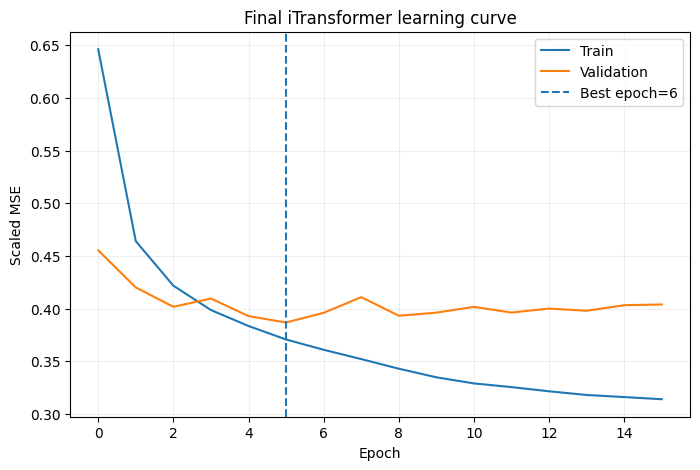

Result saved: /content/itransformer_optuna_result.csv


In [9]:
# ============================================================
# 7. RESULT SUMMARY + LEARNING CURVE
# ============================================================

lead_result_df = pd.DataFrame({
    "lead_hour": LEAD_HOURS,
    "rmse": lead_rmse,
})

display(lead_result_df)

summary = {
    "overall_rmse": overall_rmse,
    "best_epoch": final["best_epoch"],
    "best_val_mse": final["best_val"],
    "n_features": len(BEST_FEATURES),
    "selected_features": ", ".join(BEST_FEATURES),
    "selected_groups": ", ".join(
        best_trial.user_attrs["selected_groups"]
    ),
}

summary.update(BEST_MODEL_PARAMS)

summary_df = pd.DataFrame([summary])

display(summary_df)

summary_df.to_csv(
    RESULT_PATH,
    index=False,
    encoding="utf-8-sig",
)

history = final["history"]

plt.figure(figsize=(8, 5))

plt.plot(
    history["train_loss"],
    label="Train",
)

plt.plot(
    history["val_loss"],
    label="Validation",
)

plt.axvline(
    final["best_epoch"] - 1,
    linestyle="--",
    label=f"Best epoch={final['best_epoch']}",
)

plt.xlabel("Epoch")
plt.ylabel("Scaled MSE")
plt.title("Final iTransformer learning curve")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

print("Result saved:", RESULT_PATH)


In [10]:
# ============================================================
# 8. SAVE MODEL + SCALERS
# ============================================================

checkpoint = {
    "model_state_dict": final["best_state"],
    "base_features": BASE_FEATURES,
    "selected_features": BEST_FEATURES,
    "selected_groups": best_trial.user_attrs[
        "selected_groups"
    ],
    "all_candidate_features": ALL_FEATURES,
    "feature_groups": FEATURE_GROUPS,
    "best_model_params": BEST_MODEL_PARAMS,
    "input_len": INPUT_LEN,
    "lead_hours": LEAD_HOURS,
    "split_time": str(SPLIT_TIME),
    "best_epoch": final["best_epoch"],
    "best_val_mse": final["best_val"],
    "overall_rmse": overall_rmse,
    "lead_rmse": lead_rmse,
}

torch.save(
    checkpoint,
    MODEL_PATH,
)

with open(
    SCALER_PATH,
    "wb",
) as f:

    pickle.dump(
        {
            "x_scaler": x_scaler,
            "y_scaler": y_scaler,
            "all_features": ALL_FEATURES,
            "selected_features": BEST_FEATURES,
        },
        f,
    )

print("=" * 80)
print("SAVED")
print("=" * 80)
print("Model :", MODEL_PATH)
print("Scaler:", SCALER_PATH)
print("Trials:", TRIALS_PATH)
print("Result:", RESULT_PATH)


SAVED
Model : /content/itransformer_optuna_best.pt
Scaler: /content/itransformer_optuna_scalers.pkl
Trials: /content/itransformer_optuna_trials.csv
Result: /content/itransformer_optuna_result.csv


In [ ]:
# ============================================================
# 9. TEST INFERENCE + COMPETITION SUBMISSION
# Run this cell after the model and scaler save cell.
# ============================================================

def add_test_features(context):
    numeric_columns = [
        "hs", "tp", "hmax", "wvdir", "wspd", "gust",
        "wdir", "airt", "relh", "caph",
    ]
    required = {
        "case_id", "station", "step_minute", "hs", "tp", "hmax",
        "wvdir", "wspd", "gust", "wdir", "airt", "relh", "caph",
    }
    missing = sorted(required - set(context.columns))
    if missing:
        raise ValueError(f"test_context is missing columns: {missing}")

    feature_frames = []
    for case_id, group in context.groupby("case_id", sort=False):
        group = group.sort_values("step_minute").copy()
        if len(group) != INPUT_LEN:
            raise ValueError(f"{case_id}: expected {INPUT_LEN} rows, got {len(group)}")

        # Match the training cleanup for short gaps in the 10-minute grid.
        group[numeric_columns] = group[numeric_columns].interpolate(
            method="linear", limit=2, limit_direction="both"
        )
        group[numeric_columns] = group[numeric_columns].ffill().bfill()
        group["hmax"] = np.maximum(group["hmax"], group["hs"])
        group["gust"] = np.maximum(group["gust"], group["wspd"])

        wind_radians = np.deg2rad(group["wdir"])
        group["u_wind"] = group["wspd"] * np.sin(wind_radians)
        group["v_wind"] = group["wspd"] * np.cos(wind_radians)
        group["wspd_mean_6h"] = group["wspd"].rolling(36, min_periods=12).mean()
        group["wspd_mean_12h"] = group["wspd"].rolling(72, min_periods=24).mean()
        group["gust_max_6h"] = group["gust"].rolling(36, min_periods=12).max()
        group["gust_max_12h"] = group["gust"].rolling(72, min_periods=24).max()
        group["gust_minus_wspd"] = group["gust"] - group["wspd"]

        angle_difference = np.deg2rad(group["wdir"] - group["wvdir"])
        group["wind_wave_alignment"] = np.cos(angle_difference)
        group["wind_wave_diff"] = np.abs((group["wdir"] - group["wvdir"] + 180) % 360 - 180)
        group["caph_change_6h"] = group["caph"] - group["caph"].shift(36)
        group["caph_change_12h"] = group["caph"] - group["caph"].shift(72)
        group["wspd2"] = group["wspd"] ** 2
        group["wspd3"] = group["wspd"] ** 3
        group["wave_steepness_proxy"] = group["hs"] / (group["tp"] ** 2 + 1e-6)
        group["hs_tp_ratio"] = group["hs"] / (group["tp"] + 1e-6)

        # A test case starts at -48h, so early rolling and lag values have
        # no pre-context. Fill only those boundary values for inference.
        group[ALL_FEATURES] = group[ALL_FEATURES].bfill().ffill()
        feature_frames.append(group)

    return pd.concat(feature_frames, ignore_index=True)


try:
    test_context = pd.read_parquet(TEST_CONTEXT_PATH)
except ImportError as error:
    raise ImportError("Install pyarrow before inference: pip install pyarrow") from error

test_index = pd.read_csv(TEST_INDEX_PATH)
test_features = add_test_features(test_context)

with open(SCALER_PATH, "rb") as file:
    scaler_bundle = pickle.load(file)

try:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
except TypeError:
    checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)

saved_all_features = scaler_bundle["all_features"]
selected_features = checkpoint["selected_features"]
if saved_all_features != ALL_FEATURES:
    raise ValueError("Saved scaler feature order does not match this notebook.")
if not set(selected_features).issubset(test_features.columns):
    raise ValueError("A selected model feature is absent from the test context.")

case_order = test_index["case_id"].drop_duplicates().tolist()
windows = []
for case_id in case_order:
    group = test_features.loc[test_features["case_id"] == case_id].sort_values("step_minute")
    if not np.isfinite(group[saved_all_features].to_numpy(dtype=np.float32)).all():
        raise ValueError(f"{case_id}: non-finite model feature remains after preprocessing")
    windows.append(group[saved_all_features].to_numpy(dtype=np.float32))

X_test_raw = np.stack(windows)
x_scaler_saved = scaler_bundle["x_scaler"]
y_scaler_saved = scaler_bundle["y_scaler"]
X_test_all = x_scaler_saved.transform(
    X_test_raw.reshape(-1, len(saved_all_features))
).reshape(X_test_raw.shape).astype(np.float32)

feature_to_index = {feature: index for index, feature in enumerate(saved_all_features)}
selected_indices = [feature_to_index[feature] for feature in selected_features]
model_params = checkpoint["best_model_params"]
submission_model = ITransformer(
    seq_len=checkpoint["input_len"],
    n_features=len(selected_features),
    pred_len=len(checkpoint["lead_hours"]),
    d_model=model_params["d_model"],
    n_heads=model_params["n_heads"],
    e_layers=model_params["e_layers"],
    dropout=model_params["dropout"],
).to(DEVICE)
submission_model.load_state_dict(checkpoint["model_state_dict"])
submission_model.eval()

predictions = []
with torch.no_grad():
    for start in range(0, len(X_test_all), 256):
        batch = torch.from_numpy(X_test_all[start:start + 256, :, selected_indices]).to(DEVICE)
        predictions.append(submission_model(batch).cpu().numpy())

predictions = y_scaler_saved.inverse_transform(np.concatenate(predictions, axis=0))
prediction_rows = pd.DataFrame([
    {"case_id": case_id, "lead_h": lead_h, "hs_pred": float(prediction)}
    for case_id, row in zip(case_order, predictions)
    for lead_h, prediction in zip(checkpoint["lead_hours"], row)
])

submission = test_index.merge(
    prediction_rows, on=["case_id", "lead_h"], how="left", validate="one_to_one"
)[["case_id", "station", "lead_h", "hs_pred"]]
submission["hs_pred"] = submission["hs_pred"].clip(0.0, 30.0)
if len(submission) != len(test_index) or submission["hs_pred"].isna().any():
    raise ValueError("Submission rows or predictions do not match test_index.")
if not np.isfinite(submission["hs_pred"]).all():
    raise ValueError("Submission contains a non-finite hs_pred.")
if submission.columns.tolist() != ["case_id", "station", "lead_h", "hs_pred"]:
    raise ValueError("Submission column order is invalid.")

submission.to_csv(SUBMISSION_PATH, index=False, encoding="utf-8")
print(f"Saved submission: {SUBMISSION_PATH} ({len(submission)} rows)")
display(submission.head(12))
